In [9]:
import pandas as pd
import os

In [11]:
# make matplotlib pdf-s text recognizable by evil-Adobe
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

In [12]:
# Load the three RNA-seq TPM files
fib_df = pd.read_csv("Fib_genes_tpm.tsv", sep="\t")
ipsc_df = pd.read_csv("IPSC_genes_tpm.tsv", sep="\t")
mn_df = pd.read_csv("MN_genes_tpm.tsv", sep="\t")

# Merge the average TPM columns on gene_name
merged_df = fib_df[['gene_name', 'ave_tpm_fib']].merge(
    ipsc_df[['gene_name', 'ave_tpm_ipsc']],
    on='gene_name',
    how='outer'
).merge(
    mn_df[['gene_name', 'ave_tpm_mn']],
    on='gene_name',
    how='outer'
)

# Save the merged dataframe (optional)
merged_df.to_csv("merged_fib_ipsc_mn_ave_gene_tpm.tsv", sep="\t", index=False)

# Display the head of the merged dataframe
print(merged_df.head())


  gene_name  ave_tpm_fib  ave_tpm_ipsc  ave_tpm_mn
0      A1BG         3.59          3.03        2.44
1  A1BG-AS1         5.09          0.77        2.86
2      A1CF         0.00          0.02        0.04
3       A2M        12.80          0.01        1.46
4     A2ML1         0.00          1.03        0.01


In [13]:
# Load merged TPMs
merged_df = pd.read_csv("merged_fib_ipsc_mn_ave_gene_tpm.tsv", sep="\t")

# Mapping of filenames to comp_status
comp_files = {
    "AAA": "Controls_EV1_flipped_versions_v2_cut_off_005_no_adjacent_AAA_genes.txt",
    "AAB": "Controls_EV1_flipped_versions_v2_cut_off_005_no_adjacent_AAB_genes.txt",
    "ABA": "Controls_EV1_flipped_versions_v2_cut_off_005_no_adjacent_ABA_genes.txt",
    "ABB": "Controls_EV1_flipped_versions_v2_cut_off_005_no_adjacent_ABB_genes.txt",
    "BAA": "Controls_EV1_flipped_versions_v2_cut_off_005_no_adjacent_BAA_genes.txt",
    "BAB": "Controls_EV1_flipped_versions_v2_cut_off_005_no_adjacent_BAB_genes.txt",
    "BBA": "Controls_EV1_flipped_versions_v2_cut_off_005_no_adjacent_BBA_genes.txt",
    "BBB": "Controls_EV1_flipped_versions_v2_cut_off_005_no_adjacent_BBB_genes.txt",
    "NNN": "Controls_EV1_flipped_versions_v2_cut_off_005_no_adjacent_NNN_genes.txt",
}

# Build gene-to-status dictionary
gene_to_status = {}
for status, file in comp_files.items():
    with open(file, 'r') as f:
        for line in f:
            gene = line.strip()
            if gene:
                gene_to_status[gene] = status

# Add new column to merged DataFrame
merged_df['comp_status'] = merged_df['gene_name'].map(gene_to_status).fillna('NaN')

# Save output
merged_df.to_csv("merged_fib_ipsc_mn_ave_gene_tpm_with_comp_status.tsv", sep="\t", index=False)

print("✅ Merged file saved as 'merged_tpm_with_comp_status.tsv'")
# Display the head of the merged dataframe
print(merged_df.head())


✅ Merged file saved as 'merged_tpm_with_comp_status.tsv'
  gene_name  ave_tpm_fib  ave_tpm_ipsc  ave_tpm_mn comp_status
0      A1BG         3.59          3.03        2.44         NaN
1  A1BG-AS1         5.09          0.77        2.86         NaN
2      A1CF         0.00          0.02        0.04         NNN
3       A2M        12.80          0.01        1.46         NaN
4     A2ML1         0.00          1.03        0.01         BAB


In [14]:
# Count rows per comp_status, including NaN as a category
comp_counts = merged_df['comp_status'].value_counts(dropna=False)

# Print the result
print("Row counts per comp_status:")
print(comp_counts)

Row counts per comp_status:
comp_status
NaN    26110
AAA     8999
BBB     1899
BAA     1564
AAB     1103
NNN      684
ABB      644
BAB      620
BBA      318
ABA      200
Name: count, dtype: int64


In [15]:
import numpy as np

# Columns to transform
tpm_columns = ['ave_tpm_fib', 'ave_tpm_ipsc', 'ave_tpm_mn']

# Apply log10(TPM + 1)
for col in tpm_columns:
    merged_df[col] = np.log10(merged_df[col] + 1)

# Save the updated DataFrame (optional)
merged_df.to_csv("merged_fib_ipsc_mn_ave_gene_log10_tpm_with_comp_status.tsv", sep="\t", index=False)

print("✅ TPM values log10-transformed and saved to 'merged_fib_ipsc_mn_ave_gene_log10_tpm_with_comp_status.tsv'")
print(merged_df.head())

✅ TPM values log10-transformed and saved to 'merged_fib_ipsc_mn_ave_gene_log10_tpm_with_comp_status.tsv'
  gene_name  ave_tpm_fib  ave_tpm_ipsc  ave_tpm_mn comp_status
0      A1BG     0.661813      0.605305    0.536558         NaN
1  A1BG-AS1     0.784617      0.247973    0.586587         NaN
2      A1CF     0.000000      0.008600    0.017033         NNN
3       A2M     1.139879      0.004321    0.390935         NaN
4     A2ML1     0.000000      0.307496    0.004321         BAB


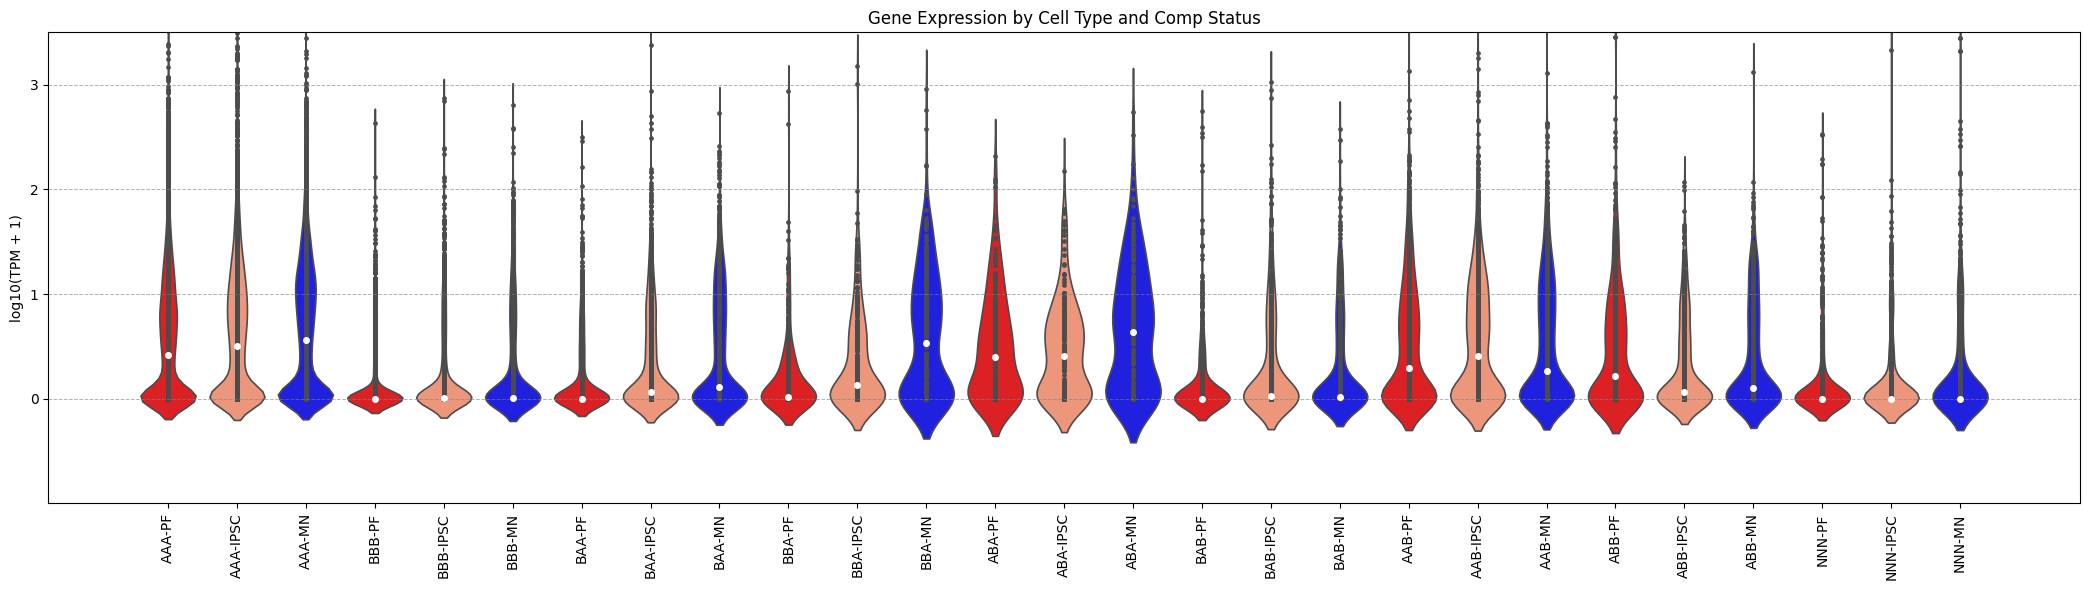

In [27]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the log10-transformed TPM data
df = pd.read_csv("merged_fib_ipsc_mn_ave_gene_log10_tpm_with_comp_status.tsv", sep="\t")

# Set comp_status as ordered category
ordered_categories = ['AAA', 'BBB', 'BAA', 'BBA', 'ABA', 'BAB', 'AAB', 'ABB', 'NNN']
df['comp_status'] = df['comp_status'].fillna('NaN')
df['comp_status'] = pd.Categorical(df['comp_status'], categories=ordered_categories, ordered=True)

# Melt the dataframe
df_melted = df.melt(
    id_vars='comp_status',
    value_vars=['ave_tpm_fib', 'ave_tpm_ipsc', 'ave_tpm_mn'],
    var_name='CellType',
    value_name='log10_TPM'
)

# Maps for colors and short labels
celltype_color_map = {
    'ave_tpm_fib': '#FB0207',
    'ave_tpm_ipsc': '#FF8C69',
    'ave_tpm_mn': '#0000FF'
}
celltype_label_map = {
    'ave_tpm_fib': 'PF',
    'ave_tpm_ipsc': 'IPSC',
    'ave_tpm_mn': 'MN'
}

# Generate group label for x-axis
df_melted['group_label'] = df_melted.apply(
    lambda x: f"{x['comp_status']}-{celltype_label_map[x['CellType']]}", axis=1
)

# Define order and color palette
group_label_order = [f"{cat}-{lab}" for cat in ordered_categories for lab in ['PF', 'IPSC', 'MN']]
palette = [celltype_color_map[label] for cat in ordered_categories for label in ['ave_tpm_fib', 'ave_tpm_ipsc', 'ave_tpm_mn']]

# Plot
plt.figure(figsize=(21, 6))
ax = sns.violinplot(
    data=df_melted,
    x='group_label',
    y='log10_TPM',
    palette=palette,
    order=group_label_order,
    linewidth=1.2,
    inner='point',
    #cut=0,
    scale='width'
)

# Highlight median points with black dots
medians = df_melted.groupby('group_label')['log10_TPM'].median()
for i, label in enumerate(group_label_order):
    median_value = medians[label]
    ax.plot(i, median_value, 'o', color='white', markersize=4, zorder=10)

# Customize y-axis
plt.ylim(-1, 3.5)
plt.yticks([0, 1, 2, 3])
# Add horizontal dashed lines
for y in [0, 1, 2, 3]:
    plt.axhline(y=y, color='gray', linestyle='--', linewidth=0.7, alpha=0.6)

# Final touches
plt.xticks(rotation=90)
plt.ylabel('log10(TPM + 1)')
plt.xlabel('')
plt.title('Gene Expression by Cell Type and Comp Status')
plt.tight_layout()

# Save plot
plt.savefig("figure2i_violin_plot_with_median_dots_eachgenepoint_log10tpmPlus1.pdf", dpi=300)
plt.show()


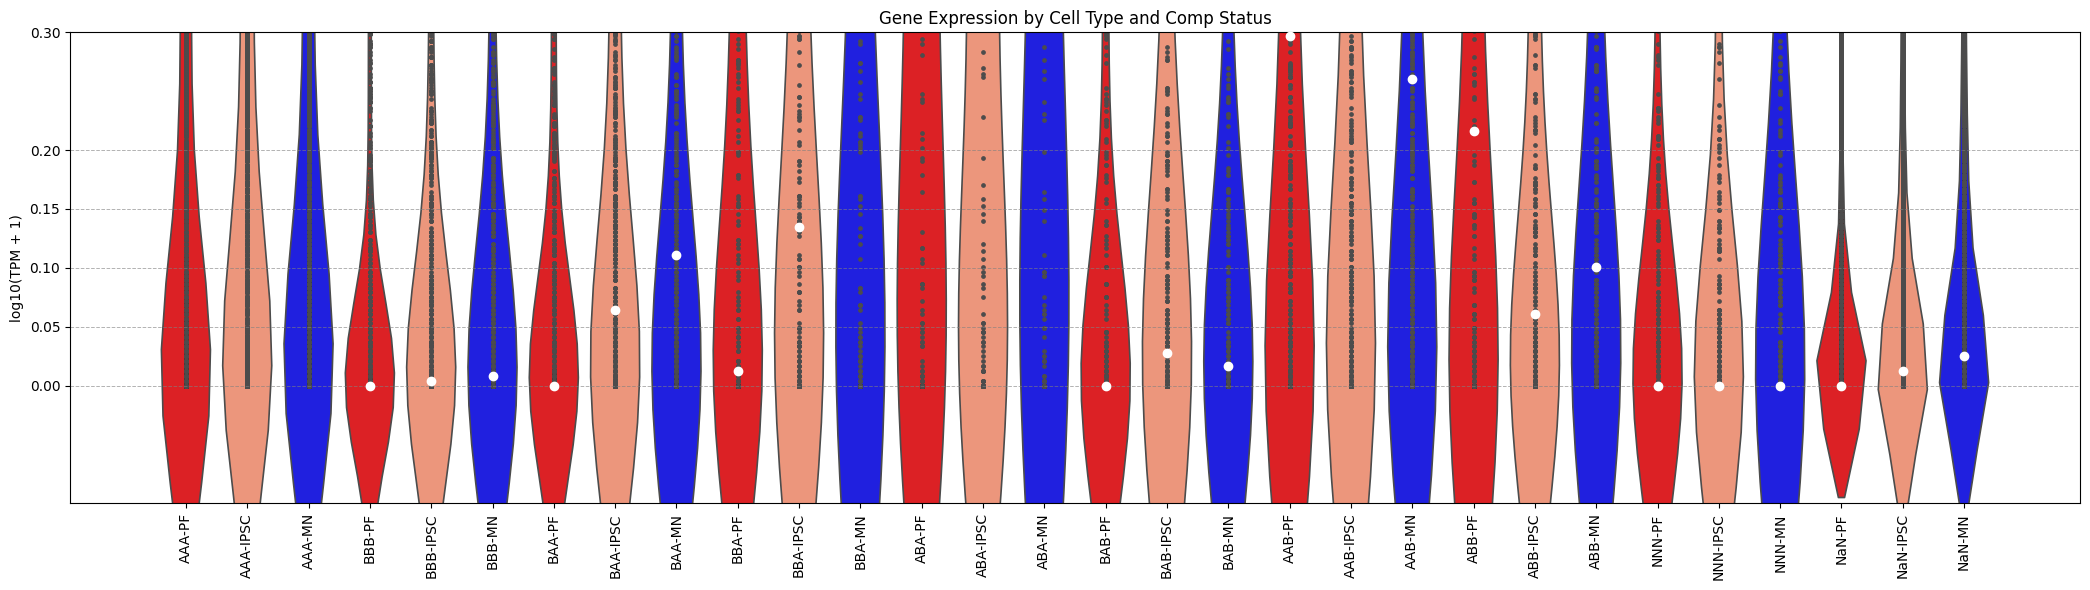

In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the log10-transformed TPM data
df = pd.read_csv("merged_fib_ipsc_mn_ave_gene_log10_tpm_with_comp_status.tsv", sep="\t")

# Set comp_status as ordered category
ordered_categories = ['AAA', 'BBB', 'BAA', 'BBA', 'ABA', 'BAB', 'AAB', 'ABB', 'NNN', 'NaN']
df['comp_status'] = df['comp_status'].fillna('NaN')
df['comp_status'] = pd.Categorical(df['comp_status'], categories=ordered_categories, ordered=True)

# Melt the dataframe
df_melted = df.melt(
    id_vars='comp_status',
    value_vars=['ave_tpm_fib', 'ave_tpm_ipsc', 'ave_tpm_mn'],
    var_name='CellType',
    value_name='log10_TPM'
)

# Maps for colors and short labels
celltype_color_map = {
    'ave_tpm_fib': '#FB0207',
    'ave_tpm_ipsc': '#FF8C69',
    'ave_tpm_mn': '#0000FF'
}
celltype_label_map = {
    'ave_tpm_fib': 'PF',
    'ave_tpm_ipsc': 'IPSC',
    'ave_tpm_mn': 'MN'
}

# Generate group label for x-axis
df_melted['group_label'] = df_melted.apply(
    lambda x: f"{x['comp_status']}-{celltype_label_map[x['CellType']]}", axis=1
)

# Define order and color palette
group_label_order = [f"{cat}-{lab}" for cat in ordered_categories for lab in ['PF', 'IPSC', 'MN']]
palette = [celltype_color_map[label] for cat in ordered_categories for label in ['ave_tpm_fib', 'ave_tpm_ipsc', 'ave_tpm_mn']]

# Plot
plt.figure(figsize=(21, 6))
ax = sns.violinplot(
    data=df_melted,
    x='group_label',
    y='log10_TPM',
    palette=palette,
    order=group_label_order,
    linewidth=1.2,
    inner='point',
    #cut=0,
    scale='width'
)

# Highlight median points with black dots
medians = df_melted.groupby('group_label')['log10_TPM'].median()
for i, label in enumerate(group_label_order):
    median_value = medians[label]
    ax.plot(i, median_value, 'o', color='white', markersize=6, zorder=10)

# Customize y-axis
plt.ylim(-0.10, 0.3)
plt.yticks([0, 0.05, 0.10, 0.15, 0.2, 0.3])
# Add horizontal dashed lines
for y in [0, 0.05, 0.10, 0.15, 0.2, 0.3]:
    plt.axhline(y=y, color='gray', linestyle='--', linewidth=0.7, alpha=0.6)

# Final touches
plt.xticks(rotation=90)
plt.ylabel('log10(TPM + 1)')
plt.xlabel('')
plt.title('Gene Expression by Cell Type and Comp Status')
plt.tight_layout()

# Save plot
plt.savefig("figure2i_violin_plot_with_median_dots_deneme.pdf", dpi=300)
plt.show()


In [5]:
seaborn.violinplot??

Object `seaborn.violinplot` not found.


In [21]:
#This is the version instead of log10 TPM+1, TPM+1 is calculated

In [22]:
# Load merged TPMs
merged_df = pd.read_csv("merged_fib_ipsc_mn_ave_gene_tpm.tsv", sep="\t")

# Mapping of filenames to comp_status
comp_files = {
    "AAA": "Controls_EV1_flipped_versions_v2_cut_off_005_no_adjacent_AAA_genes.txt",
    "AAB": "Controls_EV1_flipped_versions_v2_cut_off_005_no_adjacent_AAB_genes.txt",
    "ABA": "Controls_EV1_flipped_versions_v2_cut_off_005_no_adjacent_ABA_genes.txt",
    "ABB": "Controls_EV1_flipped_versions_v2_cut_off_005_no_adjacent_ABB_genes.txt",
    "BAA": "Controls_EV1_flipped_versions_v2_cut_off_005_no_adjacent_BAA_genes.txt",
    "BAB": "Controls_EV1_flipped_versions_v2_cut_off_005_no_adjacent_BAB_genes.txt",
    "BBA": "Controls_EV1_flipped_versions_v2_cut_off_005_no_adjacent_BBA_genes.txt",
    "BBB": "Controls_EV1_flipped_versions_v2_cut_off_005_no_adjacent_BBB_genes.txt",
    "NNN": "Controls_EV1_flipped_versions_v2_cut_off_005_no_adjacent_NNN_genes.txt",
}

# Build gene-to-status dictionary
gene_to_status = {}
for status, file in comp_files.items():
    with open(file, 'r') as f:
        for line in f:
            gene = line.strip()
            if gene:
                gene_to_status[gene] = status

# Add new column to merged DataFrame
merged_df['comp_status'] = merged_df['gene_name'].map(gene_to_status).fillna('NaN')

# Save output
merged_df.to_csv("merged_fib_ipsc_mn_ave_gene_tpm_with_comp_status.tsv", sep="\t", index=False)

print("✅ Merged file saved as 'merged_tpm_with_comp_status.tsv'")
# Display the head of the merged dataframe
print(merged_df.head())


✅ Merged file saved as 'merged_tpm_with_comp_status.tsv'
  gene_name  ave_tpm_fib  ave_tpm_ipsc  ave_tpm_mn comp_status
0      A1BG         3.59          3.03        2.44         NaN
1  A1BG-AS1         5.09          0.77        2.86         NaN
2      A1CF         0.00          0.02        0.04         NNN
3       A2M        12.80          0.01        1.46         NaN
4     A2ML1         0.00          1.03        0.01         BAB


In [23]:
# Count rows per comp_status, including NaN as a category
comp_counts = merged_df['comp_status'].value_counts(dropna=False)

# Print the result
print("Row counts per comp_status:")
print(comp_counts)

Row counts per comp_status:
comp_status
NaN    26110
AAA     8999
BBB     1899
BAA     1564
AAB     1103
NNN      684
ABB      644
BAB      620
BBA      318
ABA      200
Name: count, dtype: int64


In [24]:
# Columns to transform
tpm_columns = ['ave_tpm_fib', 'ave_tpm_ipsc', 'ave_tpm_mn']

# Apply TPM + 1 (no log)
for col in tpm_columns:
    merged_df[col] = merged_df[col] + 1

# Save the updated DataFrame
merged_df.to_csv("merged_fib_ipsc_mn_ave_gene_tpmPlus1_with_comp_status.tsv", sep="\t", index=False)

print("✅ TPM values transformed to TPM+1 and saved to 'merged_fib_ipsc_mn_ave_gene_tpmPlus1_with_comp_status.tsv'")
print(merged_df.head())

✅ TPM values transformed to TPM+1 and saved to 'merged_fib_ipsc_mn_ave_gene_tpmPlus1_with_comp_status.tsv'
  gene_name  ave_tpm_fib  ave_tpm_ipsc  ave_tpm_mn comp_status
0      A1BG         4.59          4.03        3.44         NaN
1  A1BG-AS1         6.09          1.77        3.86         NaN
2      A1CF         1.00          1.02        1.04         NNN
3       A2M        13.80          1.01        2.46         NaN
4     A2ML1         1.00          2.03        1.01         BAB


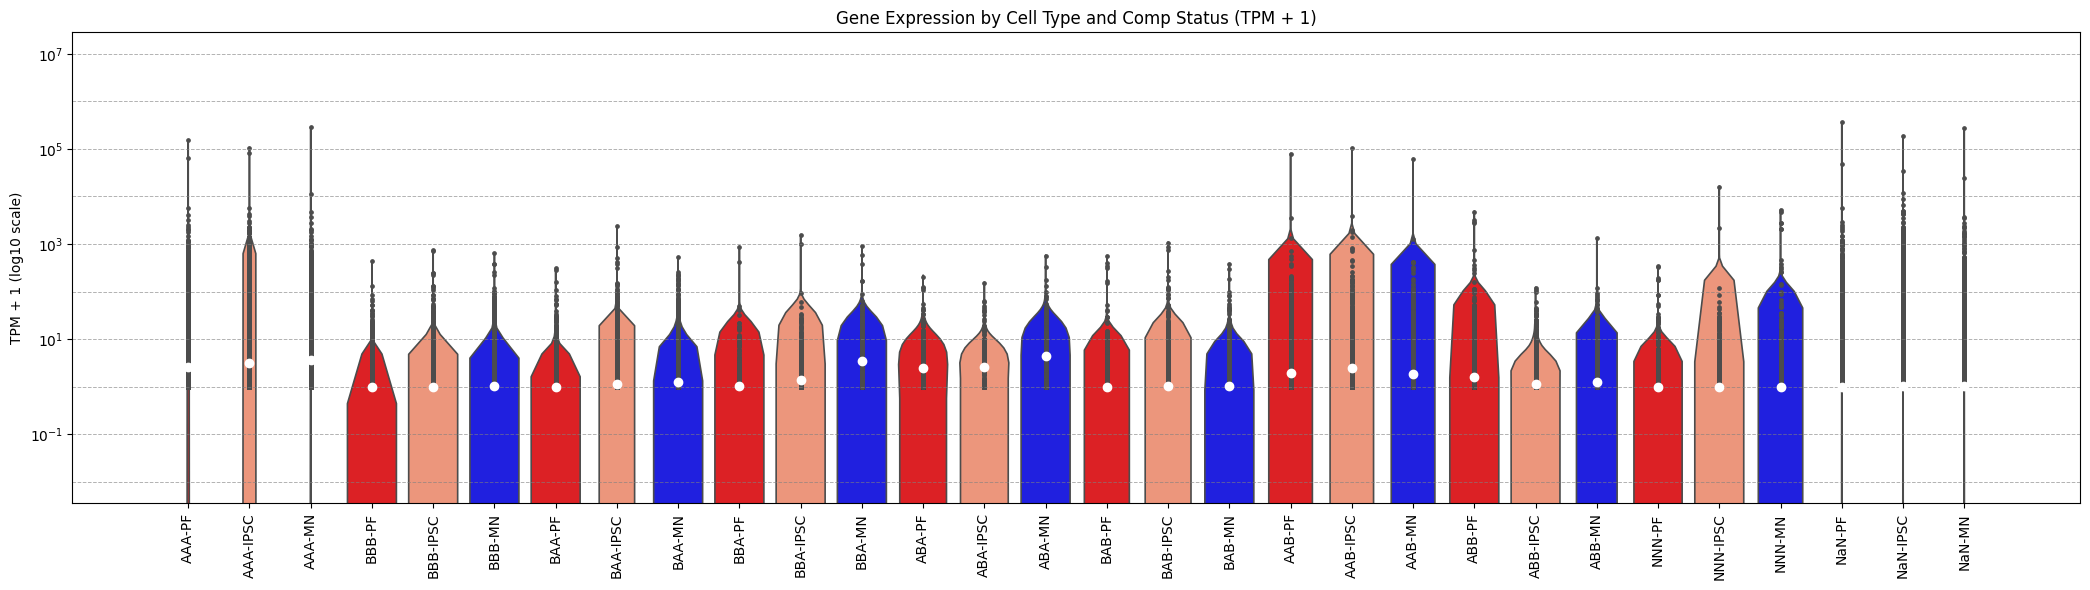

In [32]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the TPM+1 data
df = pd.read_csv("merged_fib_ipsc_mn_ave_gene_tpmPlus1_with_comp_status.tsv", sep="\t")

# Define the order of comp_status
ordered_categories = ['AAA','BBB','BAA','BBA','ABA','BAB','AAB','ABB','NNN','NaN']
df['comp_status'] = df['comp_status'].fillna('NaN')
df['comp_status'] = pd.Categorical(df['comp_status'],
                                   categories=ordered_categories,
                                   ordered=True)

# Melt into long form
df_melted = df.melt(
    id_vars='comp_status',
    value_vars=['ave_tpm_fib','ave_tpm_ipsc','ave_tpm_mn'],
    var_name='CellType',
    value_name='TPM_plus1'
)

# Color & label maps
celltype_color_map = {
    'ave_tpm_fib': '#FB0207',
    'ave_tpm_ipsc': '#FF8C69',
    'ave_tpm_mn':   '#0000FF'
}
celltype_label_map = {
    'ave_tpm_fib': 'PF',
    'ave_tpm_ipsc': 'IPSC',
    'ave_tpm_mn':   'MN'
}

# Build x-axis labels
df_melted['group_label'] = df_melted.apply(
    lambda x: f"{x['comp_status']}-{celltype_label_map[x['CellType']]}",
    axis=1
)

# Order and palette
group_label_order = [
    f"{cat}-{lab}"
    for cat in ordered_categories
    for lab in ['PF','IPSC','MN']
]
palette = [
    celltype_color_map[var]
    for _ in ordered_categories
    for var in ['ave_tpm_fib','ave_tpm_ipsc','ave_tpm_mn']
]

# Plot
plt.figure(figsize=(21, 6))
ax = sns.violinplot(
    data=df_melted,
    x='group_label',
    y='TPM_plus1',
    palette=palette,
    order=group_label_order,
    linewidth=1.2,
    inner='point',
    #cut=0,
    scale='width',
    log_scale=10,
    bw_method='silverman'
)

# Switch y-axis to log10 scale
ax.set_yscale('log')

# Overlay median dots
medians = df_melted.groupby('group_label')['TPM_plus1'].median()
for i, label in enumerate(group_label_order):
    ax.plot(i, medians[label],
            'o',
            color='white',
            markersize=6,
            zorder=10)

# Add horizontal dashed lines at each log‐tick
for y in ax.get_yticks():
    ax.axhline(y=y,
               color='gray',
               linestyle='--',
               linewidth=0.7,
               alpha=0.6)

# Final styling
plt.xticks(rotation=90)
plt.ylabel('TPM + 1 (log10 scale)')
plt.xlabel('')
plt.title('Gene Expression by Cell Type and Comp Status (TPM + 1)')
plt.tight_layout()

# Save publication‐ready PDF
plt.savefig("figure2i_violin_plot_tpmPlus1_log_scale.pdf", dpi=300)
plt.show()
